In [1]:
# =======================================================================================
#                       Etape 1 : Préparation et Transformation
# =======================================================================================

In [2]:
# ==================================
# 1. Importation des bibliothèques
# ==================================
from google.cloud import bigquery
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

In [3]:
# =========================================
# 2. Chargement et exploration des données
# =========================================
# Charger le dataset

client = bigquery.Client.from_service_account_json("key.json")

query = """
    SELECT
    *
    FROM `project-a0475dd2-d0c1-4640-aea.Sport_Metrics.mart_player`
"""

# Executer la requete
query_job = client.query(query)

# Transformer en dataframe
data = query_job.to_dataframe()

# Aperçu des premières lignes
print("Aperçu des données :\n", data.head())

# Informations générales sur les colonnes et les types de données
print("\nInformations sur le dataset :")
print(data.info())

# Statistiques descriptives
print("\nStatistiques descriptives :")
print(data.describe())

Aperçu des données :
     game_id   player_id     Season     player_name  Age  Height_cm  Weight_kg  \
0  21900931  1652212853  2019-2020  Marko Petrovic   24      208.3      103.0   
1  21900571  1652570497  2019-2020  Malik Ouattara   35      198.1       99.8   
2  21900229  1652570497  2019-2020  Malik Ouattara   35      198.1       99.8   
3  21900546  1652570497  2019-2020  Malik Ouattara   35      198.1       99.8   
4  21900869  1652570497  2019-2020  Malik Ouattara   35      198.1       99.8   

        Position  Strength_Score_last_training      Place  ... FT_PCT  \
0        Forward                          71.6  Exterieur  ...  0.000   
1  Guard-Forward                          93.4  Exterieur  ...  0.929   
2  Guard-Forward                          88.4  Exterieur  ...  1.000   
3  Guard-Forward                          79.3   Domicile  ...  1.000   
4  Guard-Forward                          94.8   Domicile  ...  1.000   

   Total_rebounds  Assists  Steals  Blocks  Turnover

In [4]:
# ==================================
# 3. Gestion des valeurs manquantes
# ==================================
# Vérification des valeurs manquantes
print(data.isnull().sum())

game_id                         0
player_id                       0
Season                          0
player_name                     0
Age                             0
Height_cm                       0
Weight_kg                       0
Position                        0
Strength_Score_last_training    0
Place                           0
Start_position                  0
minutes_played                  0
Points                          0
FG_PCT                          0
FG3_PCT                         0
FT_PCT                          0
Total_rebounds                  0
Assists                         0
Steals                          0
Blocks                          0
Turnover                        0
Player_fault                    0
Performance_score_match         0
Performance_score_match_min     0
Plus_minus                      0
dtype: int64


In [5]:
# =======================================================================================
#                       Etape 2 : Machine Learning
# =======================================================================================

In [6]:
# Séparation des variables explicatives 'indépendantes' (X) et de la variable cible 'dépendante' (y)
df = data[data["minutes_played"] >= 5]
X = df[['Height_cm', 'Weight_kg', 'Strength_Score_last_training']]
y = df['Total_rebounds'].values

# Division des données en ensemble d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Dimensions des ensembles :\nEntraînement : {X_train.shape}\nTest : {X_test.shape}")

Dimensions des ensembles :
Entraînement : (3060, 3)
Test : (766, 3)


In [7]:
# ===============================
# 1. Régression linéaire multiple
# ===============================

# Création et ajustement du modèle
linear_model = LinearRegression()

# Ajustement du modèle
linear_model.fit(X_train, y_train)

# Prédictions
y_pred = linear_model.predict(X_test)

# Affichage des coefficients
print(f'Intercept (β0): {linear_model.intercept_}')
print(f'Coefficients: {linear_model.coef_}')

# Évaluation du modèle
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"Modèle linéaire :")
print(f'Erreur quadratique moyenne (MSE): {mse:.4f}')
print(f'Coefficient de détermination (R²): {r2:.4f}')
print(f'Erreur absolue moyenne (MAE): {mae:.2f}')

Intercept (β0): -36.83958835072265
Coefficients: [ 0.23444358 -0.05892365  0.00283056]
Modèle linéaire :
Erreur quadratique moyenne (MSE): 8.0517
Coefficient de détermination (R²): 0.2240
Erreur absolue moyenne (MAE): 2.22


In [8]:
# =================================
# 2. Arbre de décision : Régression
# =================================

# Construction et ajustement de l'arbre de régression
tree_model = DecisionTreeRegressor(max_depth=3, random_state=42)
tree_model.fit(X_train, y_train)

# Prédictions sur l'ensemble de test
y_pred = tree_model.predict(X_test)

# Évaluation du modèle
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"Arbre de décision :")
print(f'Erreur quadratique moyenne (MSE): {mse:.4f}')
print(f'Coefficient de détermination (R²): {r2:.4f}')
print(f'Erreur absolue moyenne (MAE): {mae:.2f}')

Arbre de décision :
Erreur quadratique moyenne (MSE): 7.6947
Coefficient de détermination (R²): 0.2584
Erreur absolue moyenne (MAE): 2.19


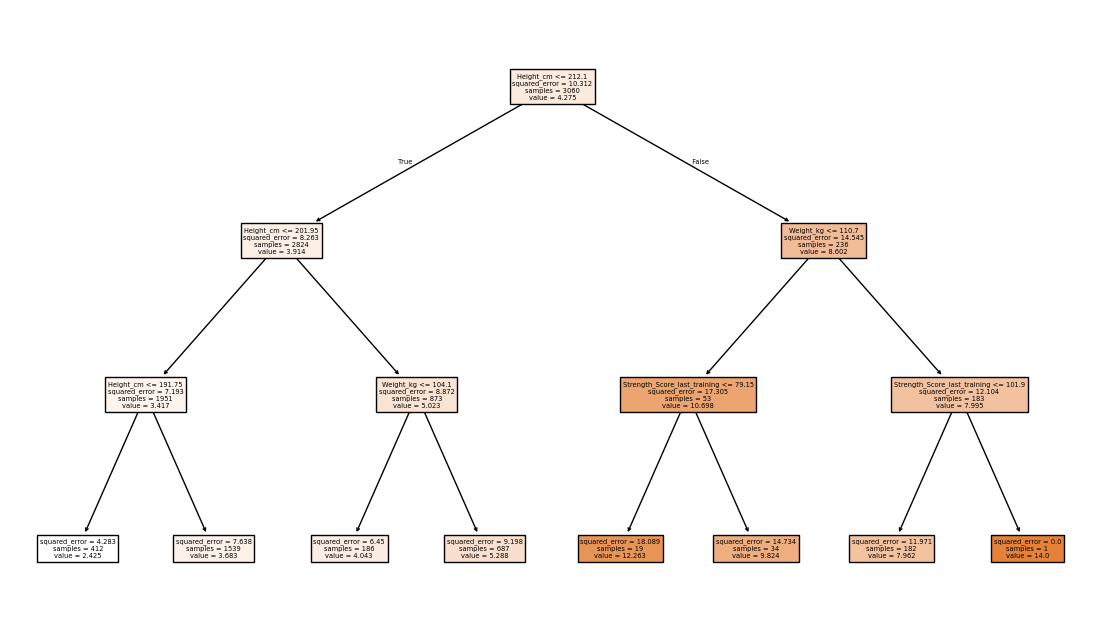

In [9]:
# Visualisation de l'arbre
plt.figure(figsize=(14, 8))
plot_tree(tree_model, feature_names=X.columns, class_names=y.unique(), filled=True)
plt.show()

In [37]:
# =================================
# 3. Forêts aléatoires : Régression
# =================================

# Construction et ajustement de la forêt aléatoire
rf_model = RandomForestRegressor(n_estimators=150, max_depth=6, random_state=42)
rf_model.fit(X_train, y_train)

# Prédictions sur l'ensemble de test
y_pred = rf_model.predict(X_test)

# Évaluation du modèle
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"Forêt aléatoire :")
print(f'Erreur quadratique moyenne (MSE): {mse:.4f}')
print(f'Coefficient de détermination (R²): {r2:.4f}')
print(f'Erreur absolue moyenne (MAE): {mae:.2f}')

Forêt aléatoire :
Erreur quadratique moyenne (MSE): 6.8125
Coefficient de détermination (R²): 0.3434
Erreur absolue moyenne (MAE): 2.05


Height_cm: 0.62
Weight_kg: 0.21
Strength_Score_last_training: 0.17


<Figure size 1000x600 with 0 Axes>

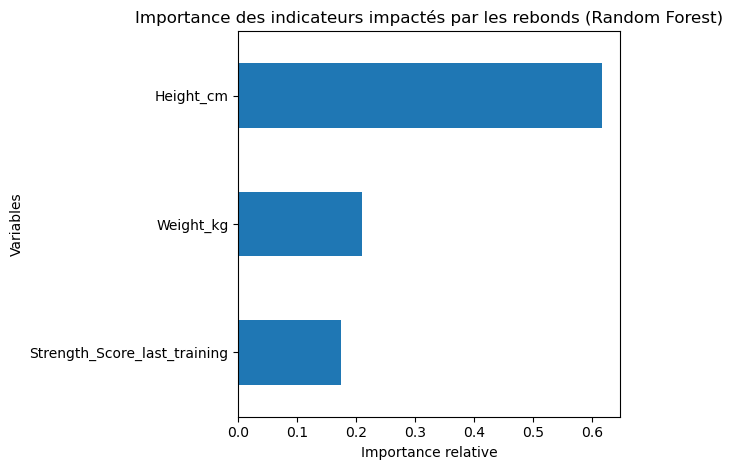

In [40]:
# Analyse et Visualisation de l'Importance des Caractéristiques
importances = rf_model.feature_importances_
feature_names = X.columns

# Affichage des importances
for name, importance in zip(feature_names, importances):
    print(f"{name}: {importance:.2f}")
    
# Création d'un DataFrame trié
df_importances = pd.DataFrame({
    'Variable': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Visualisation
plt.figure(figsize=(10, 6))
df_importances.sort_values(by='Importance', ascending=True).plot(
    kind='barh',
    x='Variable',
    y='Importance',
    legend=False
)
plt.title("Importance des indicateurs impactés par les rebonds (Random Forest)")
plt.xlabel("Importance relative")
plt.ylabel("Variables")
plt.tight_layout()
plt.show()

Conclusion :

On constace avec le graphe des importances que la taille avec un pourcentage de 62% est le facteur le plus influent sur les rebonds

On remarque que le modèle forêt est plus performant (R² ≈ 0.34, MAE = 2.05) donc, il est choisi comme modèle de prédiction pour l'impact physique.

La variance étant de 34% (sous les 50%), cela implique qu'il existe d'autres facteurs qui agissent sur les rebonds en match (fatigue, Focus, réactivité, timing, ...)